## In the previous output, file was generated with fasttree (500 bootstraps)
In this file, using IQTREE2 output ```/home/rnalab/js/logan_2/iqtree-2.3.6-Linux-intel/bin/iqtree2 -s tree3.aln -B 1000 -T AUTO --keep-ident
``` , with 1k bootstrap support for branches. the ```--keep-ident``` flag was used, as some sequences are identical in amino acid sequence, but more than 90% different when accounting for nucleotide sequences.

This should be a more "solid" representation of the tree, though likely there will be minimal differences between this one an a different one

In [1]:
%load_ext rpy2.ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

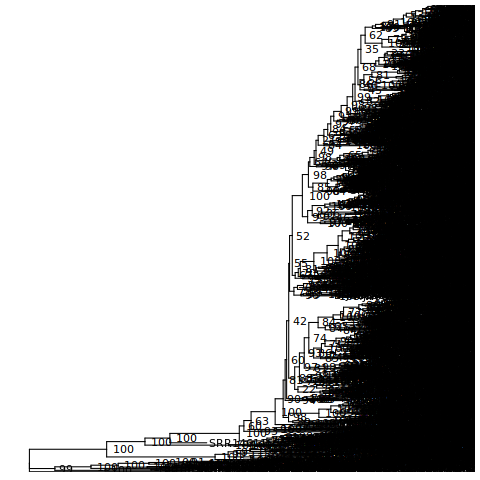

In [77]:
%%R
library(tidyverse)
library(Polychrome)
library(ggtree)
#add previously generated tip information back to the newick tree
#to visualize the tree properly
updated_tree3 <- read.tree("tree3.aln.treefile")
#bootstrap value is saved as "label" in the tree
tree <- ggtree(updated_tree3) + geom_tiplab() + geom_text(aes(label=label), hjust=-.3)
plot(tree)

In [38]:
%%R
#to get the species labels for the tips, split into pave and SRA samples
tip_labs_ncbi_novel <- as.data.frame(updated_tree3[["tip.label"]])
colnames(tip_labs_ncbi_novel) <- c("ncbi_and_novel_tip")
#1039 entries, the fasttree one got rid of the dupes. will need to reparse some stuff here

In [39]:
%%R
#deal with SRA stuff, separate out for a clean input list
SRA_ncbi_and_novel <- as.data.frame(grep("[SED][R]{2}", tip_labs_ncbi_novel$ncbi_and_novel_tip, value = T ))
colnames(SRA_ncbi_and_novel) <- c('ncbi_and_novel_SRA')
SRA_ncbi_and_novel$ncbi_and_novel_SRA_info <- SRA_ncbi_and_novel$ncbi_and_novel_SRA
SRA_ncbi_and_novel <- SRA_ncbi_and_novel %>% separate(ncbi_and_novel_SRA, into = c("library", "info"), sep="_")
#grep with this
write.table(SRA_ncbi_and_novel$library, "ncbi_and_novel_SRA_tree3.txt", sep = "\t", col.names = F, row.names = F, quote = F)

In addition: Warning message:
Expected 2 pieces. Additional pieces discarded in 234 rows [1, 2, 3, 4, 5, 6,
7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...]. 


In [ ]:
%%bash
zstd -dc "/home/rnalab/js/sra_taxid.csv.zst" | grep -f "/home/rnalab/js/pv_3/ncbi_and_novel_SRA_tree3.txt" | awk 'BEGIN {FS=",";OFS="\t"} {print $1, $6}' | sed -e 's/"//g' > ncbi_and_novel_sra_info_tree3.txt

In [42]:
%%R
#deal with new sra entries. ncbi should not be changed?
SRA_entrez_nn <- read.table("ncbi_and_novel_sra_info_tree3.txt", sep = "\t", header = F)
#clean up a little
colnames(SRA_entrez_nn) <- c("library", "species")
SRA_entrez_nn <- SRA_entrez_nn[!duplicated(SRA_entrez_nn), ]

In [43]:
%%R
#annotate information on to the sra-only dataframe
SRA_merge <- left_join(SRA_ncbi_and_novel, SRA_entrez_nn, by = "library")
SRA_merge <- select(SRA_merge, ncbi_and_novel_SRA_info, species)

In [67]:
%%R
#add previously generated tip information back to the newick tree
#read back in for complete ncbi stuff
ncbi_tags_manual <- read.table("ncbi_tags_manual.txt", sep = "\t", header = T)
colnames(ncbi_tags_manual) <- c('Newick_label', 'status') 
ncbi_tags_manual_and_sra <- rbind(SRA_merge_info_merge3, ncbi_tags_manual)
colnames(ncbi_tags_manual) <- c('Newick_label', 'uhhh') 
ncbi_tags_manual$Newick_label <- sub("-", "\\.", ncbi_tags_manual$Newick_label)

In [59]:
%%R
#combine the two labels
SRA_merge_info <- select(SRA_merge, ncbi_and_novel_SRA_info, species)
colnames(SRA_merge_info) <- c('Newick_label', 'host') 
SRA_merge_info_merge2 <- SRA_merge_info
colnames(SRA_merge_info_merge2) <- c('Newick_label', 'status')
SRA_merge_info_merge3 <- SRA_merge_info_merge2
colnames(SRA_merge_info_merge3) <- c('Newick_label', 'status') 

In [69]:
%%R
# head(ncbi_tags_manual_and_sra)
# head(SRA_merge_info)
head(ncbi_tags_manual)
# head(tip_labs_ncbi_novel)

           Newick_label         uhhh
1  KP769769.1_78_1268_1 Homo sapiens
2  MF588757.1_54_1325_1 Homo sapiens
3  MH777173.2_81_1271_1 Homo sapiens
4 KR816168.1_159_1337_1 Homo sapiens
5 HM639492.1_123_1298_1 Homo sapiens
6 LR861871.1_120_1301_1 Homo sapiens


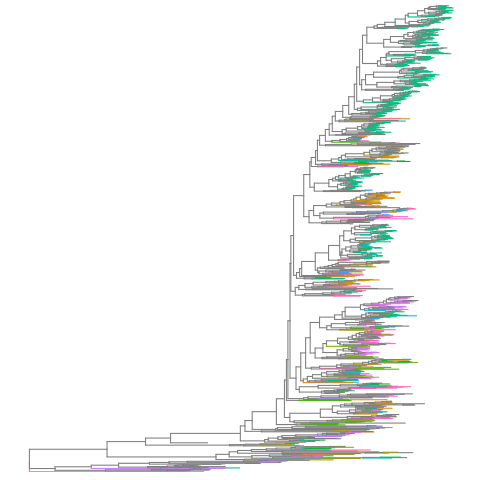

In [86]:
%%R
#annotate to tree, parse to make consistent
ncbi_tags_manual_and_sra$Newick_label <- sub("-", "\\.", ncbi_tags_manual_and_sra$Newick_label)

p <- ggtree(updated_tree3, aes(color = status)) %<+% ncbi_tags_manual_and_sra + theme(legend.position= "none")
# P50 = createPalette(251,  c("#ff0000", "#00ff00", "#0000ff"))
plot(p)
#

In addition: Warning messages:
1: Removed 1842 rows containing missing values or values outside the scale range
(`geom_text()`). 
2: Removed 1272 rows containing missing values or values outside the scale range
(`geom_text()`). 
3: Removed 1842 rows containing missing values or values outside the scale range
(`geom_text()`). 
4: Removed 1272 rows containing missing values or values outside the scale range
(`geom_text()`). 


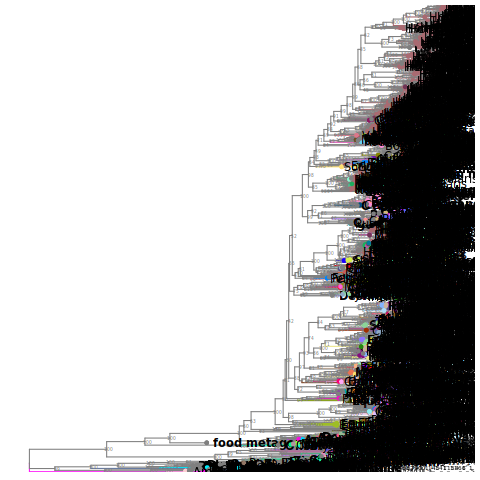

In [87]:
%%R
names(P50) <- NULL

#v2 of graph with colored branches and various other values
pp <- p + geom_tippoint() + 
  # geom_text(aes(label = species), size = 4, hjust = -0.05, color = "black") +
  # geom_tiplab(size = 2, hjust = -2.5, color = "black") +
  # geom_text(aes(label=label), hjust=-0.5, size = 2, color = "black") +
  geom_nodelab(label = p$node.label, geom = 'text', size = 1.5) +
  # scale_color_manual(values = P50) +
  theme(legend.position= "none") + 
  scale_color_manual(values = P50)


# known_ncbi_and_novel <- as.data.frame(grep("ncbi_and_novelase.|MGY", tip_labs_ncbi_novel$ncbi_and_novel_tip, value = T ))
# known_ncbi_and_novel$species <- c("known")
# colnames(known_ncbi_and_novel) <- c('Newick_label', 'status') 

ppp <- pp %<+% SRA_merge_info
pppp <- ppp + geom_tippoint() + geom_text(aes(label = host), size = 4, hjust = -0.05, color = "black", fontface = "bold") +  geom_tiplab(size = 2, hjust = -1.5, color = "black", alpha = 0) 

ppppp <- pppp %<+% ncbi_tags_manual
pppppp <- ppppp + geom_tippoint() + geom_text(aes(label = uhhh), size = 4, hjust = -0.05, color = "black") + geom_tiplab(size = 2, hjust = -2, color = "black")
# 
plot(pppppp)

ggsave("2025.02.20.ncbi_and_novel_updated_tree3.pdf", width = 150, height = 350, units = "cm", limitsize = F)
#warnings is just size issues, some are very slightly cutoff in the figure, but readable
#it's interesting that the fish clade is now placed ancestral

In [88]:
#display pdf
class PDF(object):
  def __init__(self, pdf, size=(200,200)):
    self.pdf = pdf
    self.size = size

  def _repr_html_(self):
    return '<iframe src={0} width={1[0]} height={1[1]}></iframe>'.format(self.pdf, self.size)

  def _repr_latex_(self):
    return r'\includegraphics[width=1.0\textwidth]{{{0}}}'.format(self.pdf)

PDF('2025.02.20.ncbi_and_novel_updated_tree3.pdf',size=(1000,250))
